# Grupo 1 | MCDI501 - Estadística Computacional para la Toma de Decisiones

## Integrantes
- Pablo Ignacio Balbontin Constenla @pabbalbontin-maker
- Melany Esmeralda Reyes Leiva @melanyreyesy
- Ingeborg Andrea Munoz Carnot @dark452
- Mario Alejandro Lopez Pulgar @malp2203

## Descripción del problema - Fase 2 Análisis Exploratorio e Inferencial

*Proyecto*: Predicción de la Deserción y el Éxito Académico de los Estudiantes

El dataset elegido contiene información socioeconómica, académica y demográfica de estudiantes de educación superior en Portugal. El objetivo del proyecto es predecir si un estudiante se graduará, abandonará o permanecerá matriculado, lo que permite implementar intervenciones tempranas de retención.

**Dataset:** Predict Students' Dropout and Academic Success  


## Configuración del entorno

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Reproducibilidad
np.random.seed(42)

# Estilo gráfico
plt.rcParams.update({'font.size': 10, 'figure.dpi': 120})
sns.set_style('whitegrid')

# Paleta de colores
COLORS_TARGET = {'Graduate': '#2ca02c', 'Dropout': '#d62728', 'Enrolled': '#1f77b4'}
ORDER_TARGET  = ['Graduate', 'Enrolled', 'Dropout']

# Paleta de colores para histogramas
HIST_COLORS = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#e91e63']

print('Entorno configurado.')

Entorno configurado.


## Sección 1 - Preparación y Carga de Datos

Carga del dataset, verificación de estructura, tipos de variables, identificación, documentación de faltantes, duplicados e inconsistencias, limpieza básica y reporte inicial de calidad.

### 1.1 Carga del dataset

In [2]:
def load_data(file_path: str) -> pd.DataFrame:
    """Carga dataset raw, desde un archivo CSV

    Parámetros
    ----------
    file_path : str
        Ruta del archivo CSV utilizado como entrada.

    Retorno
    -------
    pd.DataFrame
        Datos cargados en un DataFrame.

    Excepción
    ---------
    FileNotFoundError
        Si la ruta al archivo CSV no existe. Se muestra un mensaje de error
    """
    try:
        df = pd.read_csv(file_path, sep=';')
    except FileNotFoundError:
        raise FileNotFoundError(
            f"No se encontró el archivo '{file_path}'."
            "Verificar que el archivo CSV se encuentre en data/raw."
        )
    return df

In [3]:
df = load_data('../data/raw/predict_students_dropout_and_academic_success.csv')
# Limpieza de nombres: eliminar espacios y tabs residuales
df.columns = [c.strip() for c in df.columns]
print(f'Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')

print(f'\nPrimeras 3 filas:')
df.head(3)

Dataset cargado: 4,424 filas x 37 columnas

Primeras 3 filas:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout


### 1.2 Verificación de estructura y clasificación de variables

In [4]:
# Clasificación semántica de las variables
# Nota: muchas variables codificadas como int son categorías ordinales/nominales

NUMERIC_CONTIN = [
    'Previous qualification (grade)', 'Admission grade',
    'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)',
    'Unemployment rate', 'Inflation rate', 'GDP'
]

NUMERIC_DISCR = [
    'Age at enrollment',
    'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (approved)',
    'Application order'
]

CATEG_NOMINAL = ['Marital status', 'Application mode', 'Course', 'Nacionality',
                 "Mother's qualification", "Father's qualification",
                 "Mother's occupation", "Father's occupation", 'Previous qualification']

CATEG_BINARY  = ['Daytime/evening attendance', 'Displaced', 'Educational special needs',
                 'Debtor', 'Tuition fees up to date', 'Gender',
                 'Scholarship holder', 'International']

TARGET = 'Target'

print('*** Clasificación de variables ***')
print(f'  Numéricas continuas : {len(NUMERIC_CONTIN)}')
print(f'  Numéricas discretas : {len(NUMERIC_DISCR)}')
print(f'  Categóricas nominales: {len(CATEG_NOMINAL)}')
print(f'  Categóricas binarias : {len(CATEG_BINARY)}')
print(f'  Variable objetivo    : {TARGET}')
print(f'\nTotal variables analizadas: {df.shape[1]}')

*** Clasificación de variables ***
  Numéricas continuas : 7
  Numéricas discretas : 6
  Categóricas nominales: 9
  Categóricas binarias : 8
  Variable objetivo    : Target

Total variables analizadas: 37


### 1.3 Diagnóstico de calidad: valores faltantes, duplicados e inconsistencias


In [5]:
# *** Valores faltantes ***
nulls = df.isnull().sum()
null_report = nulls[nulls > 0]

print('Valores faltantes por columna:')
if null_report.empty:
    print('  ==> Sin valores faltantes. Dataset completo.')
else:
    print(null_report)

# *** Duplicados ***
n_dup = df.duplicated().sum()
print(f'\nRegistros duplicados: {n_dup}')
if n_dup == 0:
    print('  ==> Sin duplicados.')

# *** Rangos y posibles inconsistencias ***
print('\n*** Rangos de variables numéricas continuas ***')
for v in NUMERIC_CONTIN:
    print(f'  {v}: [{df[v].min():.2f}, {df[v].max():.2f}]')

# Notas fuera de rango esperado [0, 20]
grade_cols = ['Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)']
for gc in grade_cols:
    out = ((df[gc] < 0) | (df[gc] > 20)).sum()
    print(f'  Valores fuera de [0,20] en "{gc}": {out}')

# Notas de admisión [95, 190]: rango válido del sistema ENES
out_adm = ((df['Admission grade'] < 95) | (df['Admission grade'] > 190)).sum()
print(f'  Valores fuera de [95,190] en "Admission grade": {out_adm}')

Valores faltantes por columna:
  ==> Sin valores faltantes. Dataset completo.

Registros duplicados: 0
  ==> Sin duplicados.

*** Rangos de variables numéricas continuas ***
  Previous qualification (grade): [95.00, 190.00]
  Admission grade: [95.00, 190.00]
  Curricular units 1st sem (grade): [0.00, 18.88]
  Curricular units 2nd sem (grade): [0.00, 18.57]
  Unemployment rate: [7.60, 16.20]
  Inflation rate: [-0.80, 3.70]
  GDP: [-4.06, 3.51]
  Valores fuera de [0,20] en "Curricular units 1st sem (grade)": 0
  Valores fuera de [0,20] en "Curricular units 2nd sem (grade)": 0
  Valores fuera de [95,190] en "Admission grade": 0


### 1.4 Reporte de calidad consolidado


In [6]:
print('═'*55)
print('   REPORTE INICIAL DE CALIDAD DEL DATASET')
print('═'*55)
print(f'  Registros totales          : {len(df):,}')
print(f'  Variables totales          : {df.shape[1]}')
print(f'  Valores faltantes          : {df.isnull().sum().sum()} (0.0%)')
print(f'  Registros duplicados       : {df.duplicated().sum()}')
print(f'  Variables continuas        : {len(NUMERIC_CONTIN)}')
print(f'  Variables discretas        : {len(NUMERIC_DISCR)}')
print(f'  Variables categóricas      : {len(CATEG_NOMINAL) + len(CATEG_BINARY)}')
print(f'  Variable objetivo (Target) : 3 clases - Dropout, Enrolled, Graduate')
print('═'*55)
print('  ==> El dataset no requiere imputación ni eliminación de filas.')
print('  ==> Se realizó limpieza de espacios en nombres de columnas.')
print('  ==> Rangos de variables dentro de valores esperados para el dominio.')

═══════════════════════════════════════════════════════
   REPORTE INICIAL DE CALIDAD DEL DATASET
═══════════════════════════════════════════════════════
  Registros totales          : 4,424
  Variables totales          : 37
  Valores faltantes          : 0 (0.0%)
  Registros duplicados       : 0
  Variables continuas        : 7
  Variables discretas        : 6
  Variables categóricas      : 17
  Variable objetivo (Target) : 3 clases - Dropout, Enrolled, Graduate
═══════════════════════════════════════════════════════
  ==> El dataset no requiere imputación ni eliminación de filas.
  ==> Se realizó limpieza de espacios en nombres de columnas.
  ==> Rangos de variables dentro de valores esperados para el dominio.


---
## Sección 2 — Análisis Exploratorio de Datos

Estadística descriptiva de variables numéricas y categóricas con visualizaciones; análisis bivariado con correlaciones e interpretación en el contexto del problema.

### 2.1 Distribución de la variable objetivo

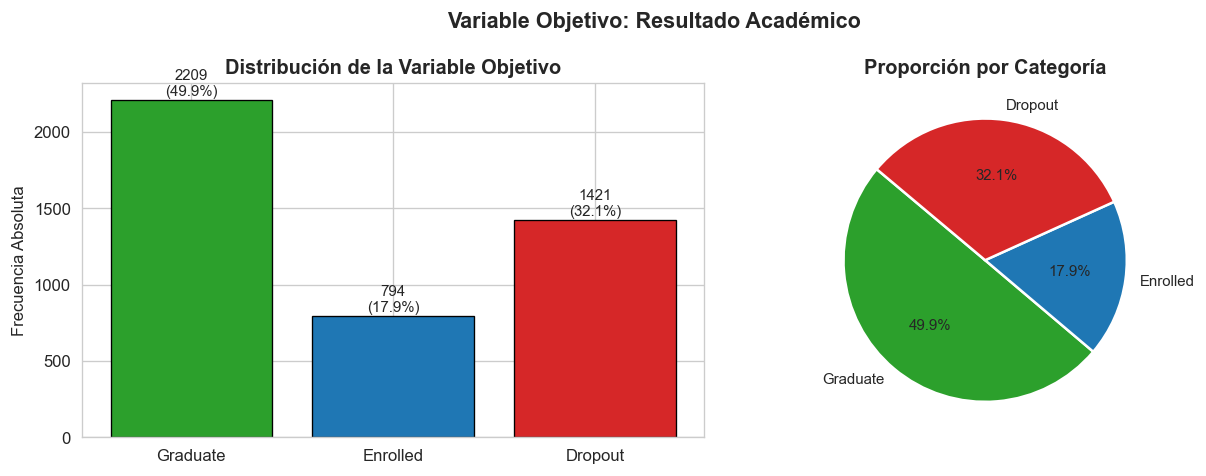


Tabla de frecuencias:
             n      %
Target               
Graduate  2209  49.93
Dropout   1421  32.12
Enrolled   794  17.95


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

vc = df['Target'].value_counts()
axes[0].bar(ORDER_TARGET, [vc[t] for t in ORDER_TARGET],
            color=[COLORS_TARGET[t] for t in ORDER_TARGET],
            edgecolor='black', linewidth=0.8)
axes[0].set_title('Distribución de la Variable Objetivo', fontweight='bold')
axes[0].set_ylabel('Frecuencia Absoluta')
for i, t in enumerate(ORDER_TARGET):
    axes[0].text(i, vc[t]+30, f'{vc[t]}\n({vc[t]/len(df)*100:.1f}%)', ha='center', fontsize=9)

sizes = [vc[t] for t in ORDER_TARGET]
axes[1].pie(sizes, labels=ORDER_TARGET, autopct='%1.1f%%',
            colors=[COLORS_TARGET[t] for t in ORDER_TARGET],
            startangle=140, textprops={'fontsize': 9},
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Proporción por Categoría', fontweight='bold')

plt.suptitle('Variable Objetivo: Resultado Académico', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig1_distribucion_target.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nTabla de frecuencias:')
freq_df = pd.DataFrame({'n': vc, '%': (vc/len(df)*100).round(2)})
print(freq_df)

**Interpretación:** El dataset presenta una distribución desequilibrada. La categoría *Graduate* concentra el 49.9% de los registros (n=2,209), seguida por *Dropout* con el 32.1% (n=1,421) y *Enrolled* con el 17.9% (n=794). Esta distribución implica que cualquier modelo predictivo deberá considerar estrategias de balanceo de clases. El alto porcentaje de abandono (≈1 de cada 3 estudiantes) confirma la relevancia del problema de investigación.

### 2.2 Estadística descriptiva de variables numéricas

In [8]:
ALL_NUM = ['Previous qualification (grade)', 'Admission grade',
           'Age at enrollment', 'Curricular units 1st sem (grade)',
           'Curricular units 2nd sem (grade)', 'Unemployment rate',
           'Inflation rate', 'GDP']

desc = df[ALL_NUM].describe().T
desc['cv'] = (desc['std'] / desc['mean'] * 100).round(2)
desc['skew'] = df[ALL_NUM].skew().round(3)
desc['kurtosis'] = df[ALL_NUM].kurtosis().round(3)
desc = desc[['count','mean','std','cv','min','25%','50%','75%','max','skew','kurtosis']]
desc.columns = ['n','Media','Desv.Est.','CV(%)','Mín','Q1','Mediana','Q3','Máx','Asimetría','Curtosis']
desc.round(3)

,n,Media,Desv.Est.,CV(%),Mín,Q1,Mediana,Q3,Máx,Asimetría,Curtosis
Previous qualification (grade),4424.0,132.613,13.188,9.94,95.00,125.00,133.100,140.000,190.000,0.313,0.968
Admission grade,4424.0,126.978,14.482,11.41,95.00,117.90,126.100,134.800,190.000,0.531,0.663
Age at enrollment,4424.0,23.265,7.588,32.61,17.00,19.00,20.000,25.000,70.000,2.055,4.127
Curricular units 1st sem (grade),4424.0,10.641,4.844,45.52,0.00,11.00,12.286,13.400,18.875,-1.568,0.908
Curricular units 2nd sem (grade),4424.0,10.230,5.211,50.94,0.00,10.75,12.200,13.333,18.571,-1.314,0.067
Unemployment rate,4424.0,11.566,2.664,23.03,7.60,9.40,11.100,13.900,16.200,0.212,-0.996
Inflation rate,4424.0,1.228,1.383,112.60,-0.80,0.30,1.400,2.600,3.700,0.252,-1.039
GDP,4424.0,0.002,2.270,115295.00,-4.06,-1.70,0.320,1.790,3.510,-0.394,-1.002


### 2.3 Histogramas de variables numéricas

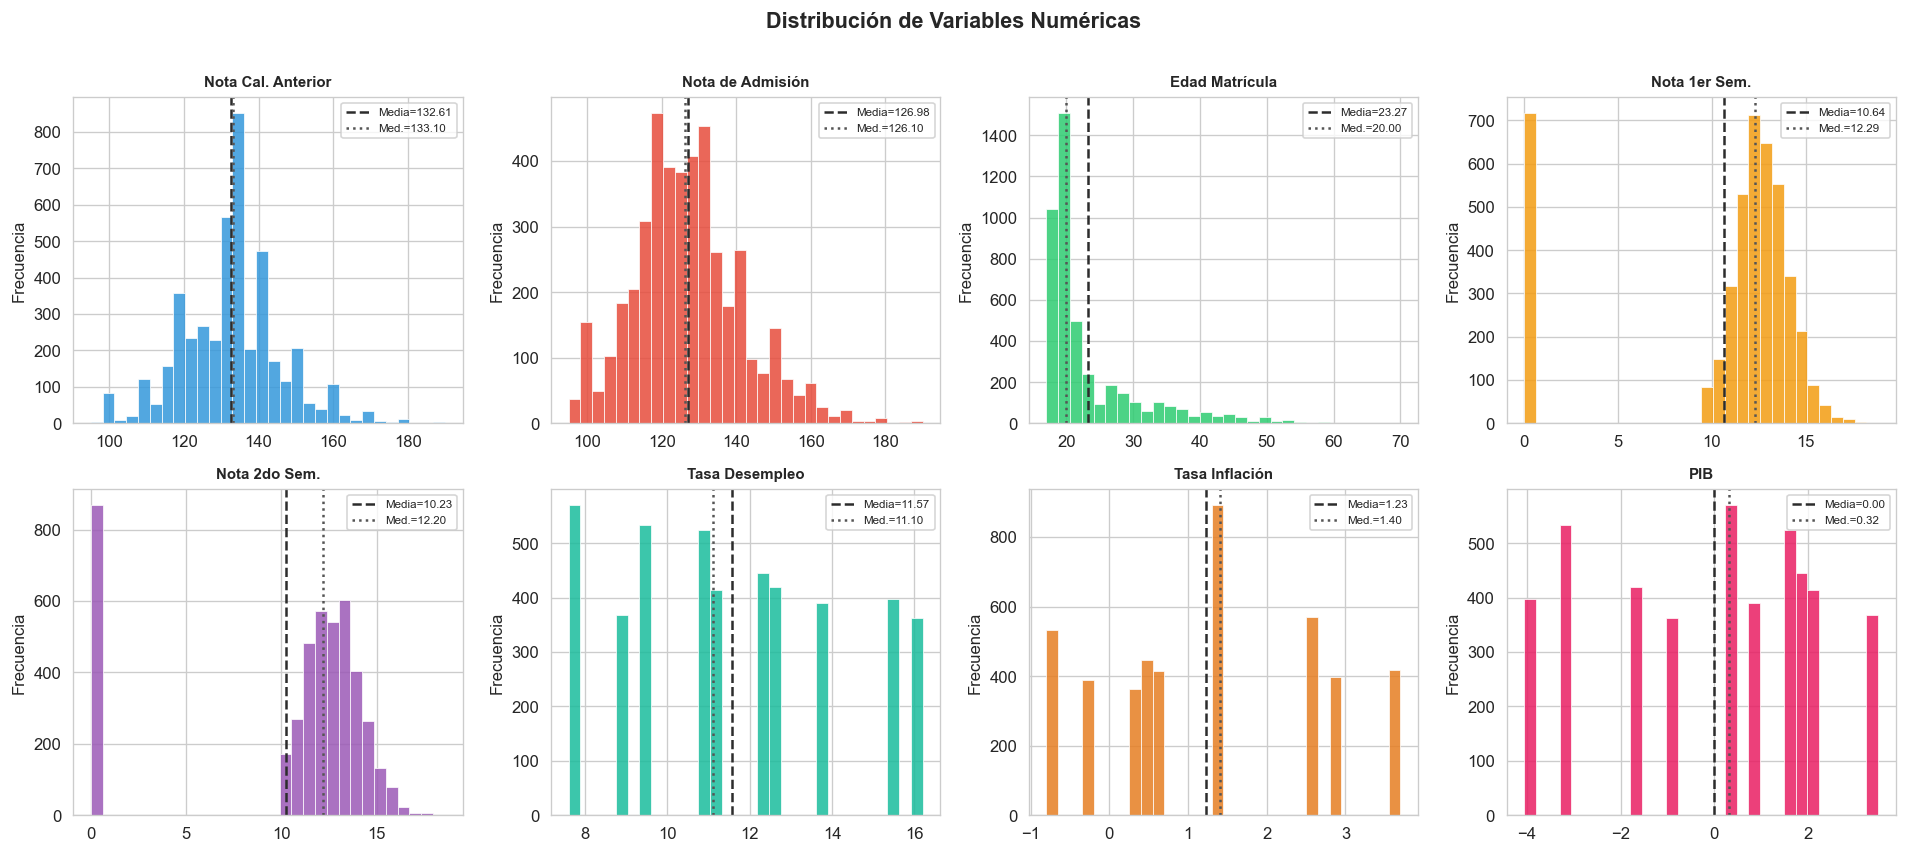

In [9]:
labels_map = {
    'Previous qualification (grade)': 'Nota Cal. Anterior',
    'Admission grade': 'Nota de Admisión',
    'Age at enrollment': 'Edad Matrícula',
    'Curricular units 1st sem (grade)': 'Nota 1er Sem.',
    'Curricular units 2nd sem (grade)': 'Nota 2do Sem.',
    'Unemployment rate': 'Tasa Desempleo',
    'Inflation rate': 'Tasa Inflación',
    'GDP': 'PIB'
}

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, var in enumerate(ALL_NUM):
    color = HIST_COLORS[i]
    axes[i].hist(df[var], bins=30, color=color, edgecolor='white',
                 linewidth=0.5, alpha=0.85)
    axes[i].axvline(df[var].mean(), color='#2c2c2c', linestyle='--',
                    linewidth=1.5, label=f'Media={df[var].mean():.2f}')
    axes[i].axvline(df[var].median(), color='#555555', linestyle=':',
                    linewidth=1.5, label=f'Med.={df[var].median():.2f}')
    axes[i].set_title(labels_map[var], fontweight='bold', fontsize=9)
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(fontsize=7)

plt.suptitle('Distribución de Variables Numéricas', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/fig2_histogramas.png', bbox_inches='tight', dpi=150)
plt.show()

**Interpretación:** Las notas de admisión y calificación previa muestran distribuciones aproximadamente simétricas con leve asimetría negativa, lo que indica que la mayoría de los estudiantes ingresan con notas en el rango medio-alto (120-140 sobre 190). La *Edad al matricularse* presenta asimetría positiva marcada (cola hacia la derecha), con mayoría de estudiantes jóvenes (moda ≈ 19-20 años) pero presencia de estudiantes adultos (hasta 70 años). Las tasas macroeconómicas (desempleo, inflación, PIB) reflejan el contexto económico portugués del período cubierto por el dataset.

### 2.4 Variables categóricas: frecuencias y gráficos

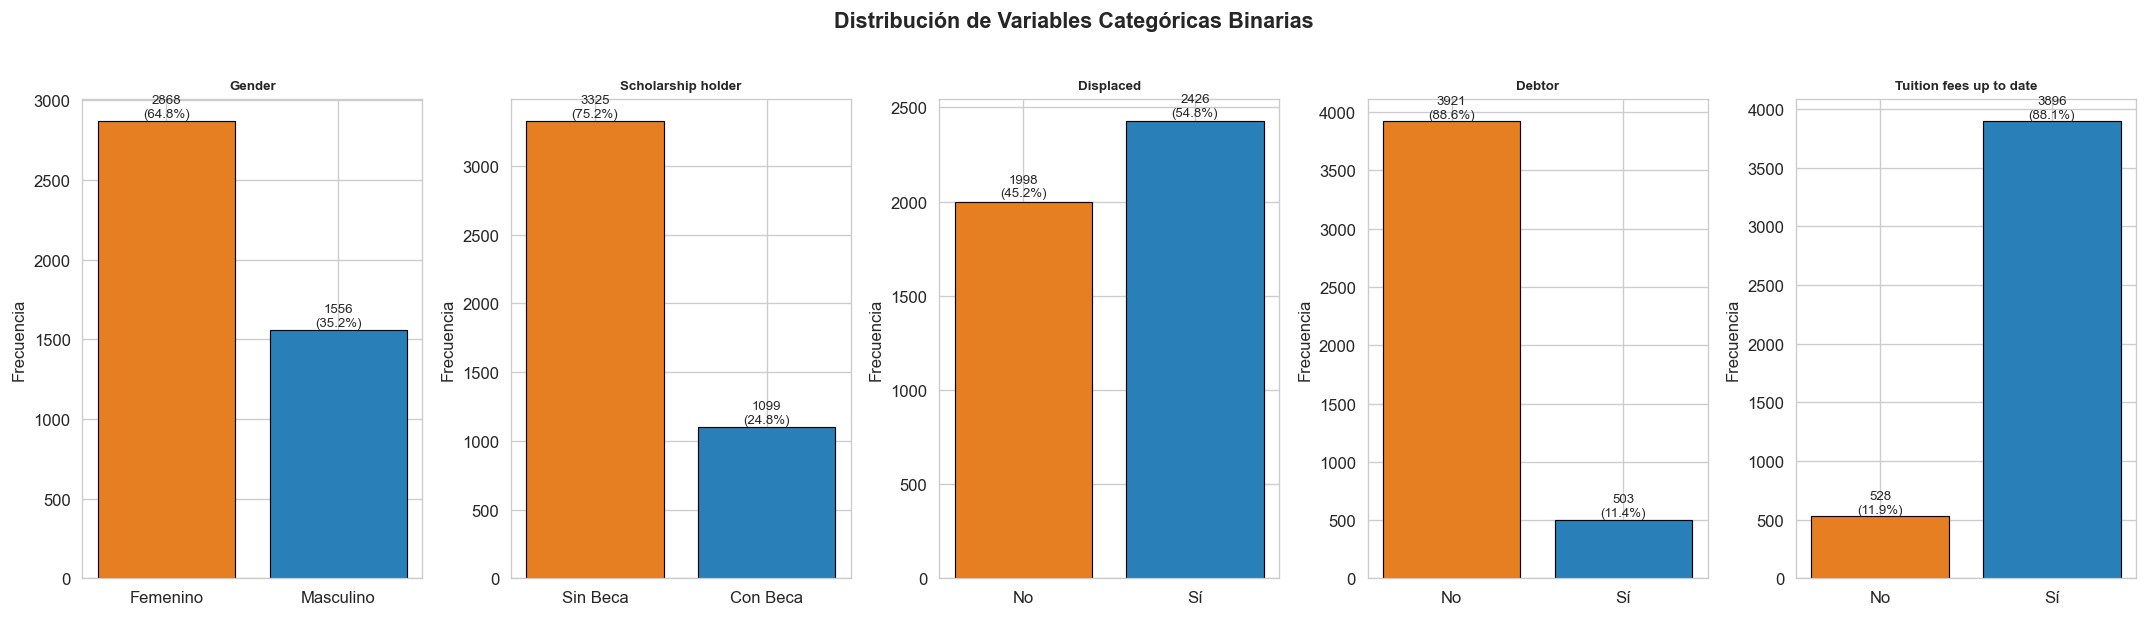


Frecuencias absolutas y relativas:

Gender:
  Femenino: n=2868 (64.8%)
  Masculino: n=1556 (35.2%)

Scholarship holder:
  Sin Beca: n=3325 (75.2%)
  Con Beca: n=1099 (24.8%)

Displaced:
  No: n=1998 (45.2%)
  Sí: n=2426 (54.8%)

Debtor:
  No: n=3921 (88.6%)
  Sí: n=503 (11.4%)

Tuition fees up to date:
  No: n=528 (11.9%)
  Sí: n=3896 (88.1%)


In [10]:
cat_binary = ['Gender', 'Scholarship holder', 'Displaced', 'Debtor', 'Tuition fees up to date']
cat_labels = ['Género\n(0=F, 1=M)', 'Becado', 'Desplazado', 'Deudor', 'Matrícula al Día']
cat_map = {
    'Gender': {0: 'Femenino', 1: 'Masculino'},
    'Scholarship holder': {0: 'Sin Beca', 1: 'Con Beca'},
    'Displaced': {0: 'No', 1: 'Sí'},
    'Debtor': {0: 'No', 1: 'Sí'},
    'Tuition fees up to date': {0: 'No', 1: 'Sí'}
}
BAR_COLORS = ['#e67e22', '#2980b9']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, (var, lab) in enumerate(zip(cat_binary, cat_labels)):
    vc2 = df[var].value_counts().sort_index()
    labels_bar = [cat_map[var].get(k, str(k)) for k in vc2.index]
    axes[i].bar(labels_bar, vc2.values,
                color=BAR_COLORS, edgecolor='black', linewidth=0.7)
    axes[i].set_title(var, fontweight='bold', fontsize=8)
    axes[i].set_ylabel('Frecuencia')
    for j, v in enumerate(vc2.values):
        axes[i].text(j, v+30, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=8)

plt.suptitle('Distribución de Variables Categóricas Binarias', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/fig5_categoricas.png', bbox_inches='tight', dpi=150)
plt.show()

# Tabla de frecuencias
print('\nFrecuencias absolutas y relativas:')
for var in cat_binary:
    vc3 = df[var].value_counts().sort_index()
    pct = (vc3/len(df)*100).round(1)
    print(f'\n{var}:')
    for k in vc3.index:
        print(f'  {cat_map[var].get(k,k)}: n={vc3[k]} ({pct[k]}%)')

### 2.5 Análisis bivariado: variables clave por resultado académico

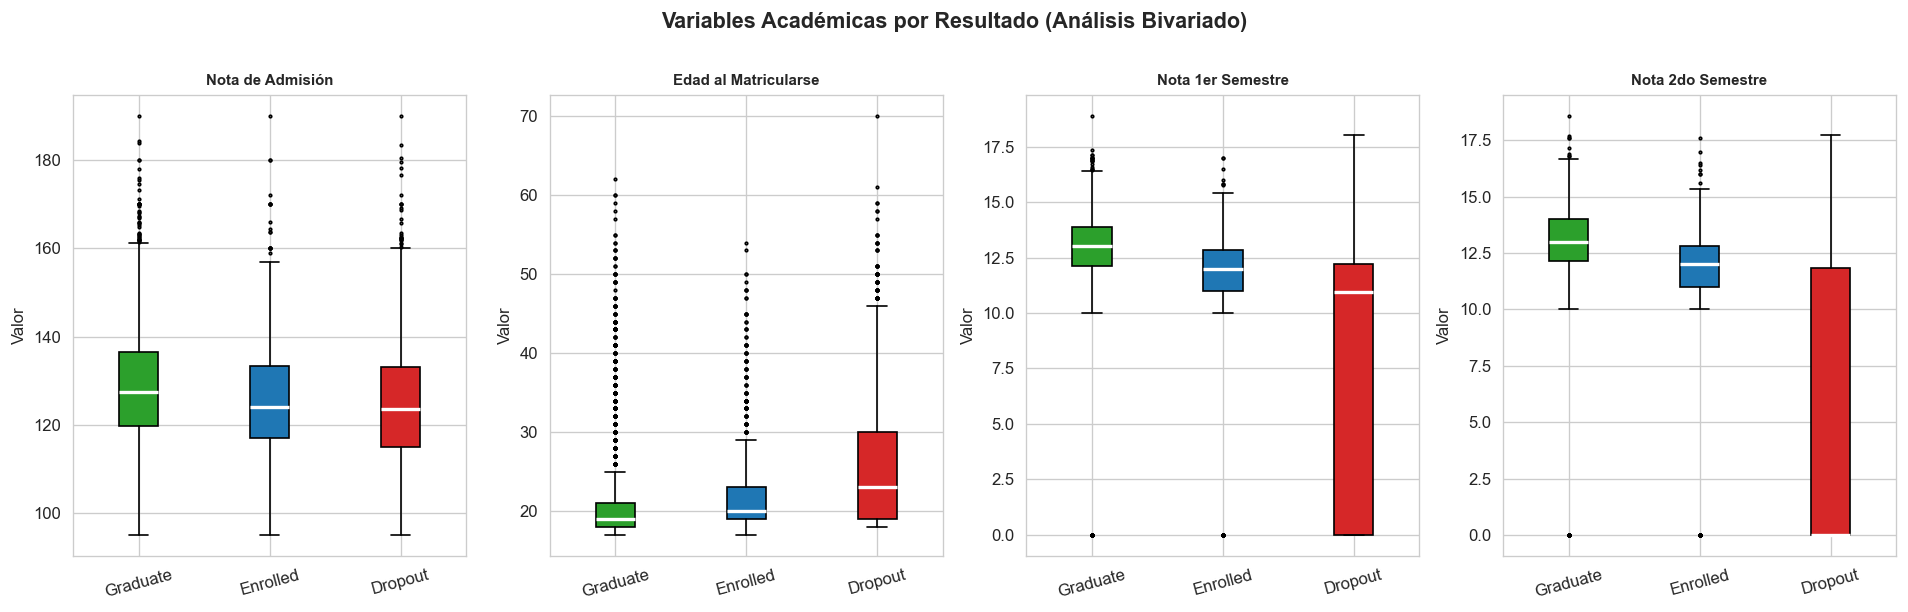


Medias por grupo:
Target                            Dropout  Enrolled  Graduate
Admission grade                   124.961   125.534   128.794
Age at enrollment                  26.069    22.369    21.784
Curricular units 1st sem (grade)    7.257    11.125    12.644
Curricular units 2nd sem (grade)    5.899    11.117    12.697


In [11]:
key_vars = ['Admission grade', 'Age at enrollment',
            'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)']
key_labs = ['Nota de Admisión', 'Edad al Matricularse',
             'Nota 1er Semestre', 'Nota 2do Semestre']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
palette = COLORS_TARGET

for i, (var, lab) in enumerate(zip(key_vars, key_labs)):
    data_plot = [df[df['Target']==t][var].values for t in ORDER_TARGET]
    bp = axes[i].boxplot(data_plot, labels=ORDER_TARGET, patch_artist=True,
                         medianprops={'color': 'white', 'linewidth': 2},
                         whiskerprops={'color': 'black'},
                         capprops={'color': 'black'},
                         flierprops={'marker': '.', 'markersize': 3, 'color': '#999999'})
    for patch, t in zip(bp['boxes'], ORDER_TARGET):
        patch.set_facecolor(palette[t])
    axes[i].set_title(lab, fontweight='bold', fontsize=9)
    axes[i].set_ylabel('Valor')
    axes[i].tick_params(axis='x', labelrotation=15)

plt.suptitle('Variables Académicas por Resultado (Análisis Bivariado)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/fig3_boxplots_target.png', bbox_inches='tight', dpi=150)
plt.show()

# Medias por grupo
print('\nMedias por grupo:')
print(df.groupby('Target')[key_vars].mean().round(3).T.to_string())

**Interpretación:** Los boxplots revelan patrones consistentes y estadísticamente relevantes:

- **Nota de Admisión:** Los graduados presentan notas de admisión superiores (μ≈128.8) respecto a los desertores (μ≈124.9), diferencia que se analizará formalmente en la Sección 4.
- **Edad:** Los desertores tienen una edad de matrícula mayor (μ≈26.1 años) comparado con los graduados (μ≈21.8 años), sugiriendo que los estudiantes adultos enfrentan mayores barreras para completar sus estudios.
- **Notas de 1° y 2° semestre:** Este es el factor más discriminante. Los graduados obtienen notas significativamente más altas (mediana ≈12-13), mientras que los desertores concentran notas cercanas a 0, indicando que muchos abandonan sin completar evaluaciones.
- El rendimiento del 1° semestre actúa como un indicador temprano confiable del resultado final.

### 2.6 Matriz de correlación

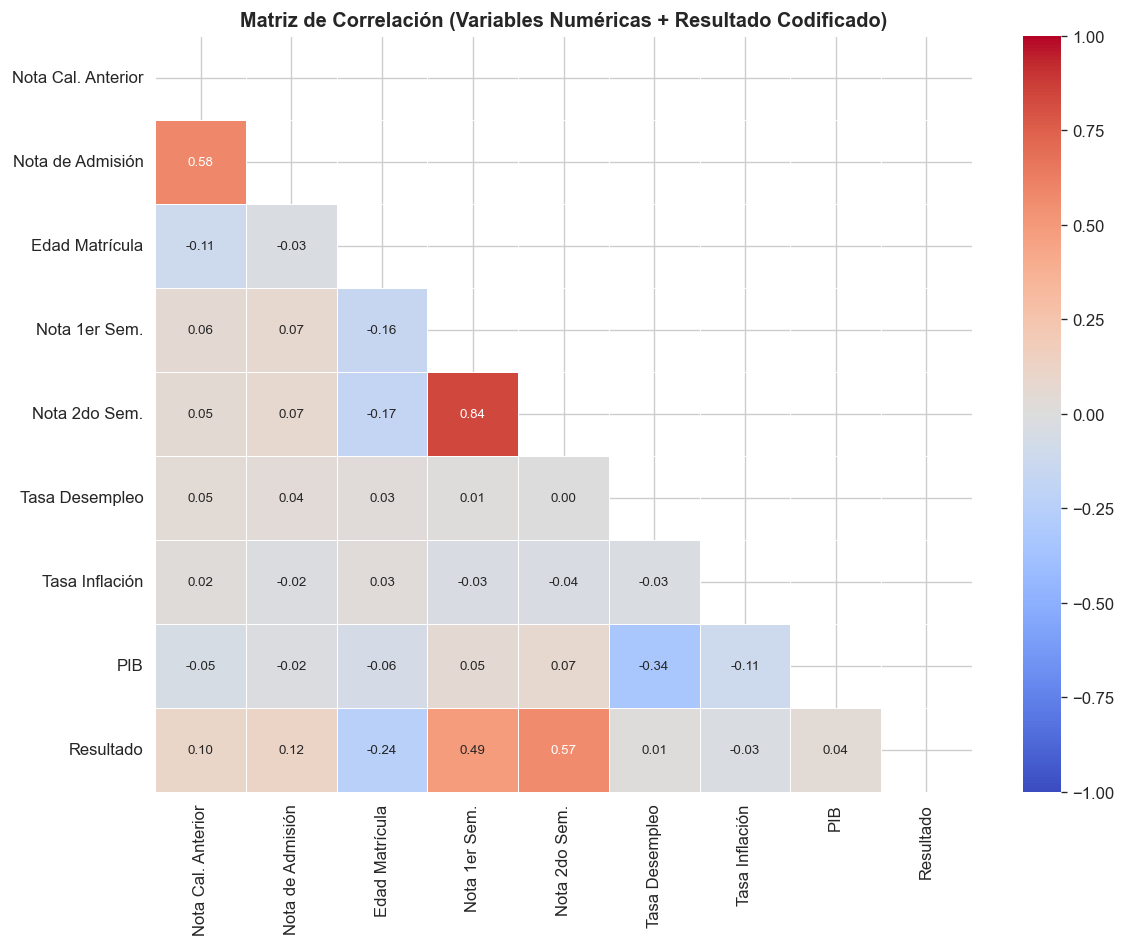


Correlaciones con Target_num (ordenadas):
  Nota 2do Sem.                 : r = +0.5668
  Nota 1er Sem.                 : r = +0.4852
  Nota de Admisión              : r = +0.1209
  Nota Cal. Anterior            : r = +0.1038
  PIB                           : r = +0.0441
  Tasa Desempleo                : r = +0.0086
  Tasa Inflación                : r = -0.0269
  Edad Matrícula                : r = -0.2434


In [12]:
df_enc = df.copy()
df_enc['Target_num'] = df_enc['Target'].map({'Dropout': 0, 'Enrolled': 1, 'Graduate': 2})

corr_vars = ALL_NUM + ['Target_num']
corr_labels = [labels_map[v] for v in ALL_NUM] + ['Resultado']
corr_matrix = df_enc[corr_vars].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1, ax=ax,
            linewidths=0.5,
            xticklabels=corr_labels, yticklabels=corr_labels,
            annot_kws={'size': 8})
ax.set_title('Matriz de Correlación (Variables Numéricas + Resultado Codificado)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../data/processed/fig4_correlacion.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nCorrelaciones con Target_num (ordenadas):')
corr_target = corr_matrix['Target_num'].drop('Target_num').sort_values(ascending=False)
for var, r in corr_target.items():
    print(f'  {labels_map.get(var, var):30s}: r = {r:+.4f}')

**Interpretación:** Las notas del 1° y 2° semestre son las variables con mayor correlación positiva con el resultado (r=0.49 y r=0.57 respectivamente), confirmando que el rendimiento académico semestral es el predictor más fuerte de graduación. La edad al matricularse presenta correlación negativa moderada (r=−0.24), indicando que mayor edad se asocia a mayor riesgo de abandono. Las variables macroeconómicas (desempleo, inflación, PIB) muestran correlaciones muy débiles con el resultado individual, lo que sugiere que factores académicos internos dominan sobre el contexto económico externo.